In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pickle
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import os, glob
from typing import List, Tuple, Optional
from pathlib import Path
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')


In [2]:
READOUT_KEY = '23343-5-17'

In [3]:
# real neurons population against which we compare synthetic data
chosen_response_dir = '/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium/static' + READOUT_KEY + '-GrayImageNet-94c6ff995dac583098847cfecd43e7b6/data/responses'

In [14]:
    # load coordinates
coords_path = ("/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/cell_motor_coordinates.npy")
coords = np.load(coords_path)

In [4]:
def load_mouse_responses(folder: str) -> np.ndarray:   
    """
    Load all trials from folder as a matrix of shape (T, N).
    Assumes each file i.npy is a vector of length N (responses for trial i across N neurons).
    """
    files = glob.glob(os.path.join(folder, '*.npy'))
    files.sort(key=lambda p: int(Path(p).stem))
    data = np.stack([np.load(f) for f in files], axis=0) 
    return data

In [ ]:
import os
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# SAVE_DIR = './real_data_stats_figures'
# os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------------
# helpers
# ------------------------------------------------------------------
def session_key_from_dir(responses_dir: str) -> str:
    # e.g. static23343-5-17-GrayImageNet... -> 23343-5-17
    name = Path(responses_dir).parts[-3]
    assert name.startswith("static")
    return name[len("static"):].split("-GrayImageNet")[0]

def load_responses(responses_dir: str) -> np.ndarray:
    files = glob.glob(os.path.join(responses_dir, '*.npy'))
    files.sort(key=lambda p: int(Path(p).stem))
    data = np.stack([np.load(f) for f in files], axis=0)  # shape (T, N)
    return data

def compute_basic_stats(data: np.ndarray) -> dict:
    per_neuron_mean = data.mean(axis=0)
    per_neuron_var = data.var(axis=0)
    return {
        "T": data.shape[0],
        "N": data.shape[1],
        "per_neuron_mean": per_neuron_mean,
        "per_neuron_var": per_neuron_var,
        "mean_mean": float(per_neuron_mean.mean()),
        "mean_var": float(per_neuron_var.mean()),
    }

def compute_corr(data: np.ndarray) -> np.ndarray:
    # columns are neurons
    return np.corrcoef(data, rowvar=False)

def upper_triangle_values(M: np.ndarray) -> np.ndarray:
    iu = np.triu_indices_from(M, k=1)
    vals = M[iu]
    return vals[np.isfinite(vals)]

def sparse_ticks(n, max_ticks=8):
    if n <= max_ticks:
        return np.arange(n)
    return np.unique(np.linspace(0, n - 1, max_ticks, dtype=int))




In [6]:
real_data = load_mouse_responses(chosen_response_dir)
real_stats = compute_basic_stats(real_data)
print(real_stats["T"], real_stats["N"],
        "mean_var =", real_stats["mean_var"])

5951 7334 mean_var = 185.98248291015625


In [49]:
import numpy as np
import matplotlib.pyplot as plt

def plot_figure_C(session_data, real_data=None, savepath=None, regime_title=None):
    data = session_data
    corr = compute_corr(data)

    # load coordinates
    coords_path = "/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/cell_motor_coordinates.npy"
    coords = np.load(coords_path)

    # primary sort by y, secondary by x
    order = np.lexsort((coords[:, 0], coords[:, 1]))
    corr_ord = corr[order][:, order]

    mask = np.tril(np.ones_like(corr_ord, dtype=bool), k=-1)
    corr_plot = corr_ord.copy()
    corr_plot[mask] = np.nan

    # upper triangle only for histogram
    corr_vals = upper_triangle_values(corr)

    # eigenspectrum of synthetic correlation matrix
    eigvals = np.linalg.eigvalsh(corr)
    eigvals = np.linalg.eigvalsh(corr)
    eigvals = eigvals[::-1]

    # sample correlation matrix rank is at most min(N, T-1)
    T = data.shape[0]
    rmax = min(corr.shape[0], T - 1)

    eigvals_use = eigvals[:rmax]
    eigvals_norm = eigvals_use / eigvals_use.sum()

    # optional real data comparison
    if real_data is not None:
        corr_real = compute_corr(real_data)
        corr_vals_real = upper_triangle_values(corr_real)
       
        eigvals_real = np.linalg.eigvalsh(corr_real)
        eigvals_real = eigvals_real[::-1]

        T_real = real_data.shape[0]
        rmax_real = min(corr_real.shape[0], T_real - 1)

        eigvals_real_use = eigvals_real[:rmax_real]
        eigvals_real_norm = eigvals_real_use / eigvals_real_use.sum()
    else:
        corr_vals_real = None
        eigvals_real_norm = None

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    # histogram
    bins = np.linspace(-1, 1, 81)
    axes[0].hist(corr_vals, bins=bins, density=True, alpha=0.7, label='Synthetic')
    if corr_vals_real is not None:
        counts_real, edges_real = np.histogram(corr_vals_real, bins=bins, density=True)
        centers_real = 0.5 * (edges_real[:-1] + edges_real[1:])
        axes[0].plot(centers_real, counts_real, linewidth=2, label='Real')
    axes[0].set_title('Pairwise correlations', fontsize=14)
    axes[0].set_xlabel('Pearson r', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=10)
    axes[0].legend(fontsize=10)

    # heatmap (synthetic only)
    im = axes[1].imshow(corr_plot, vmin=-1, vmax=1, cmap='coolwarm', interpolation='nearest')
    axes[1].set_title('Correlation heatmap', fontsize=14)
    axes[1].set_xlabel('Spatially ordered neuron index', fontsize=12)
    axes[1].set_ylabel('Spatially ordered neuron index', fontsize=12)
    ticks = sparse_ticks(corr_plot.shape[0], max_ticks=6)
    axes[1].set_xticks(ticks)
    axes[1].set_yticks(ticks)
    axes[1].tick_params(axis='both', labelsize=9)
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Pearson r', fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # eigenspectrum
    x = np.arange(1, len(eigvals_norm) + 1)
    axes[2].plot(x, eigvals_norm, marker='o', markersize=2, linewidth=1, label='Synthetic')
    if eigvals_real_norm is not None:
        x_real = np.arange(1, len(eigvals_real_norm) + 1)
        axes[2].plot(x_real, eigvals_real_norm, linewidth=2, label='Real')
    axes[2].set_yscale('log')
    axes[2].set_title('Eigenspectrum', fontsize=14)
    axes[2].set_xlabel('Component index', fontsize=12)
    axes[2].set_ylabel('Normalized eigenvalue', fontsize=12)
    axes[2].tick_params(axis='both', labelsize=10)
    axes[2].legend(fontsize=10)

    if regime_title is not None:
        fig.suptitle(regime_title, fontsize=15, y=1.05)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()

## Stimulus-dominated

In [36]:
K = 4
ALPHA = 0
session = load_mouse_responses(f'/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium/k_{K}_a_{ALPHA}_beta1e7_poisson/data/responses')

In [37]:
# ------------------------------------------------------------------
# load all sessions once
# ------------------------------------------------------------------

session_stats = compute_basic_stats(session)
print(session_stats["T"], session_stats["N"],
        "mean_var =", session_stats["mean_var"])

25448 7334 mean_var = 3.7442263436095033


In [ ]:
# ------------------------------------------------------------------
# paths
# ------------------------------------------------------------------
real_response_dirs = [
    '/user/azhar.akhmetova/corrViT/V1T/data/sensorium/static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6/data/responses',
    '/user/azhar.akhmetova/corrViT/V1T/data/sensorium/static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6/data/responses',
    '/user/azhar.akhmetova/corrViT/V1T/data/sensorium/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6/data/responses',
    '/user/azhar.akhmetova/corrViT/V1T/data/sensorium/static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6/data/responses',
    '/user/azhar.akhmetova/corrViT/V1T/data/sensorium/static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6/data/responses',
]

In [51]:
# ------------------------------------------------------------------
# Figure A: across-session boxplots of per-neuron means and variances
# ------------------------------------------------------------------
def plot_figure_A(session_stats, ref_key=REF_KEY, savepath=None):
    keys = list(session_stats.keys())
    mean_data = [session_stats[k]["per_neuron_mean"] for k in keys]
    var_data  = [session_stats[k]["per_neuron_var"] for k in keys]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    bp1 = axes[0].boxplot(mean_data, tick_labels=keys, showfliers=False, patch_artist=True)
    bp2 = axes[1].boxplot(var_data, tick_labels=keys, showfliers=False, patch_artist=True)

    for i, k in enumerate(keys):
        color = 'lightcoral' if k == ref_key else 'lightgray'
        bp1['boxes'][i].set_facecolor(color)
        bp2['boxes'][i].set_facecolor(color)

    axes[0].set_title('Per-neuron mean responses across sessions', fontsize=14)
    axes[0].set_xlabel('Session', fontsize=12)
    axes[0].set_ylabel('Mean response', fontsize=12)
    axes[0].tick_params(axis='x', rotation=30, labelsize=10)
    axes[0].tick_params(axis='y', labelsize=10)

    axes[1].set_title('Per-neuron response variances across sessions', fontsize=14)
    axes[1].set_xlabel('Session', fontsize=12)
    axes[1].set_ylabel('Variance', fontsize=12)
    axes[1].set_yscale('log')
    axes[1].tick_params(axis='x', rotation=30, labelsize=10)
    axes[1].tick_params(axis='y', labelsize=10)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

# ------------------------------------------------------------------
# Figure B: histograms for the chosen session
# ------------------------------------------------------------------
def plot_figure_B(session_stats, savepath=None):
    stats = session_stats
    means = stats["per_neuron_mean"]
    vars_ = stats["per_neuron_var"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    bin_width_mean = 0.5
    bins_mean = np.arange(means.min(), means.max() + bin_width_mean, bin_width_mean)
    axes[0].hist(means, bins=bins_mean)
    axes[0].set_title(f'Per-neuron means', fontsize=14)
    axes[0].set_xlabel('Mean response', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=10)

    positive_vars = vars_[vars_ > 0]
    log_bins = np.logspace(np.log10(positive_vars.min()), np.log10(positive_vars.max()), 60)
    axes[1].hist(positive_vars, bins=log_bins)
    axes[1].set_xscale('log')
    axes[1].set_title(f'Per-neuron variances', fontsize=14)
    axes[1].set_xlabel('Variance', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].tick_params(axis='both', labelsize=10)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

# ------------------------------------------------------------------
# Figure C: correlation histogram, ordered heatmap, eigenspectrum
# ------------------------------------------------------------------
def plot_figure_C(session_data, savepath=None):
    data = session_data
    corr = compute_corr(data)

    # load coordinates
    coords_path = ("/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/cell_motor_coordinates.npy")
    coords = np.load(coords_path)

    # primary sort by y, secondary by x
    order = np.lexsort((coords[:, 0], coords[:, 1]))
    corr_ord = corr[order][:, order]

    mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)
    corr_plot = corr_ord.copy()
    corr_plot[mask] = np.nan

    # upper triangle only for histogram
    corr_vals = upper_triangle_values(corr)

    # eigenspectrum of correlation matrix
    eigvals = np.linalg.eigvalsh(corr)
    eigvals = eigvals[::-1]
    eigvals_pos = eigvals[eigvals > 1e-10]
    eigvals_norm = eigvals_pos / eigvals_pos.sum()

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    # histogram
    bins = np.linspace(-1, 1, 81)
    axes[0].hist(corr_vals, bins=bins, density=True)
    axes[0].set_title(f'Pairwise correlations', fontsize=14)
    axes[0].set_xlabel('Pearson r', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=10)

    # heatmap
    im = axes[1].imshow(corr_plot, vmin=-1, vmax=1, cmap='coolwarm', interpolation='nearest')
    axes[1].set_title(f'Correlation heatmap', fontsize=14)
    axes[1].set_xlabel('Spatially ordered neuron index', fontsize=12)
    axes[1].set_ylabel('Spatially ordered neuron index', fontsize=12)
    ticks = sparse_ticks(corr_plot.shape[0], max_ticks=6)
    axes[1].set_xticks(ticks)
    axes[1].set_yticks(ticks)
    axes[1].tick_params(axis='both', labelsize=9)
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Pearson r', fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # eigenspectrum
    x = np.arange(1, len(eigvals_norm) + 1)
    axes[2].plot(x, eigvals_norm, marker='o', markersize=2, linewidth=1)
    axes[2].set_yscale('log')
    axes[2].set_title(f'Eigenspectrum', fontsize=14)
    axes[2].set_xlabel('Component index', fontsize=12)
    axes[2].set_ylabel('Normalized eigenvalue', fontsize=12)
    axes[2].tick_params(axis='both', labelsize=10)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    fig.suptitle(rf'Stimulus-dominated regime, $\alpha = 0$', fontsize=15)
    plt.show()




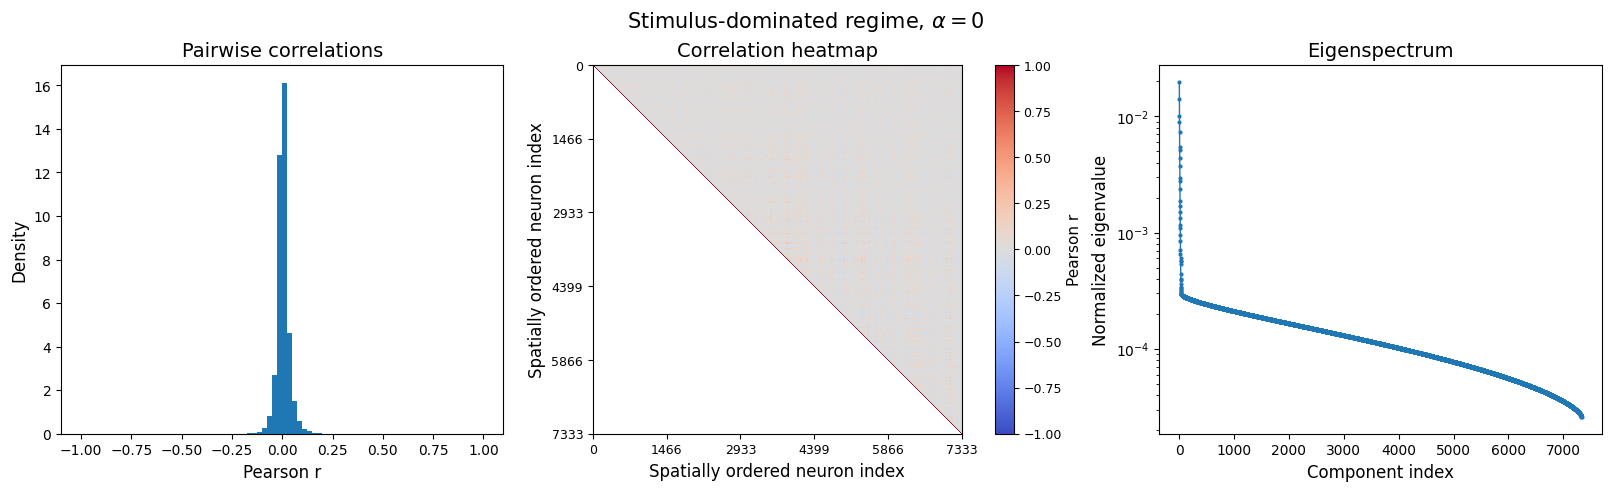

In [52]:
# ------------------------------------------------------------------
# run all
# ------------------------------------------------------------------
# plot_figure_A(
#     session_stats,
#     ref_key=REF_KEY,
#     savepath=os.path.join(SAVE_DIR, 'figure_A_across_session_stats.png')
# )

# plot_figure_B(
#     session_stats,
# )

plot_figure_C(
    session,
)

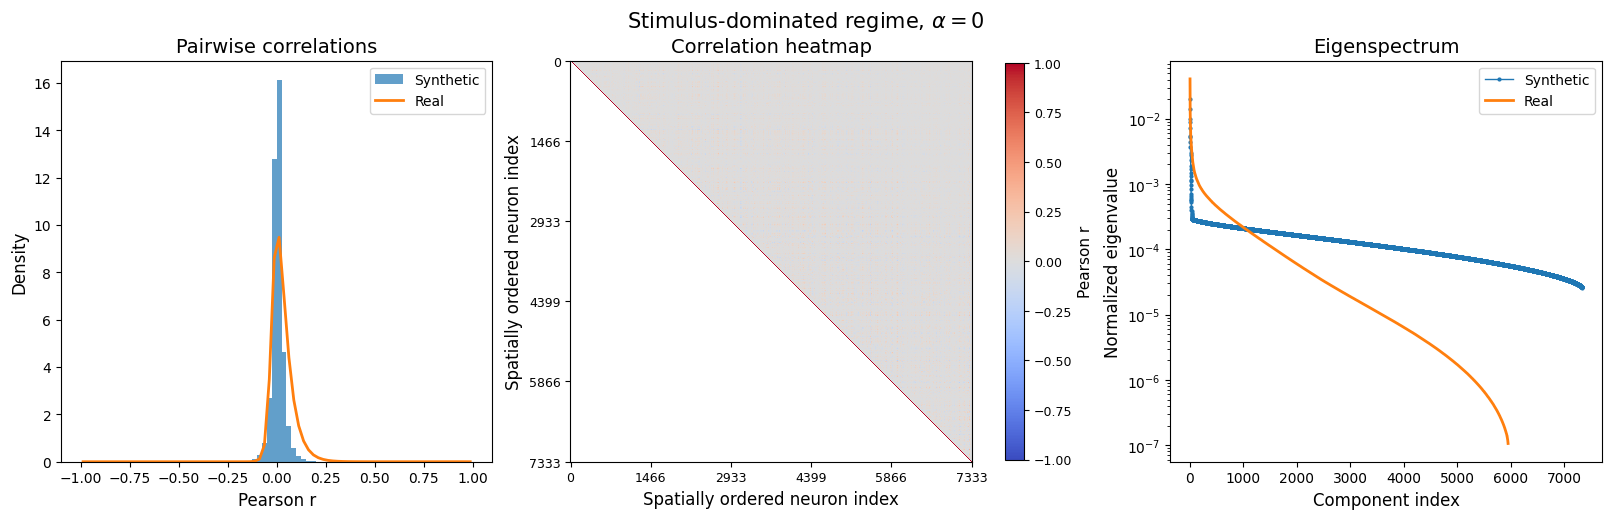

In [50]:
plot_figure_C(
    session_data=session,
    real_data=real_data,
    # savepath='stimdom_corr_compare.png',
    regime_title=rf'Stimulus-dominated regime, $\alpha=0$'
)

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def plot_figure_B(session_stats, real_stats=None, savepath=None):
    """
    session_stats: dict with keys 'per_neuron_mean', 'per_neuron_var'
                  usually synthetic stats you want as histogram bars
    real_stats: optional dict with same keys, plotted as line overlay
    """
    means = session_stats["per_neuron_mean"]
    vars_ = session_stats["per_neuron_var"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

    # ---------------------------
    # Means
    # ---------------------------
    bin_width_mean = 0.5

    if real_stats is not None:
        means_real = real_stats["per_neuron_mean"]
        mean_min = min(means.min(), means_real.min())
        mean_max = max(means.max(), means_real.max())
    else:
        mean_min, mean_max = means.min(), means.max()

    bins_mean = np.arange(mean_min, mean_max + bin_width_mean, bin_width_mean)

    # synthetic / main histogram as bars
    axes[0].hist(means, bins=bins_mean, alpha=0.7, label=rf'Synthetic ($\alpha$=0)')

    # real histogram as line
    if real_stats is not None:
        counts_real, edges_real = np.histogram(means_real, bins=bins_mean)
        centers_real = 0.5 * (edges_real[:-1] + edges_real[1:])
        axes[0].plot(centers_real, counts_real, linewidth=2, label='Real')

    axes[0].set_title(rf'Per-neuron means', fontsize=14)
    axes[0].set_xlabel('Mean response', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=10)
    if real_stats is not None:
        axes[0].legend(fontsize=10)

    # ---------------------------
    # Variances
    # ---------------------------
    positive_vars = vars_[vars_ > 0]

    if real_stats is not None:
        vars_real = real_stats["per_neuron_var"]
        positive_vars_real = vars_real[vars_real > 0]
        var_min = min(positive_vars.min(), positive_vars_real.min())
        var_max = max(positive_vars.max(), positive_vars_real.max())
    else:
        var_min, var_max = positive_vars.min(), positive_vars.max()

    # fixed width in log10-space
    log_bin_width = 0.1
    log_min = np.log10(var_min)
    log_max = np.log10(var_max)
    bins_var = 10 ** np.arange(log_min, log_max + log_bin_width, log_bin_width)

    # synthetic / main histogram as bars
    axes[1].hist(positive_vars, bins=bins_var, alpha=0.7, label=rf'Synthetic ($\alpha$=0)')

    # real histogram as line
    if real_stats is not None:
        counts_real_var, edges_real_var = np.histogram(positive_vars_real, bins=bins_var)
        centers_real_var = np.sqrt(edges_real_var[:-1] * edges_real_var[1:])  # geometric centers for log axis
        axes[1].plot(centers_real_var, counts_real_var, linewidth=2, label='Real')

    axes[1].set_xscale('log')
    axes[1].set_title('Per-neuron variances', fontsize=14)
    axes[1].set_xlabel('Variance', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].tick_params(axis='both', labelsize=10)
    if real_stats is not None:
        axes[1].legend(fontsize=10)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    # fig.suptitle(rf'Stimulus-dominated regime, $\alpha = 0$', fontsize=14)
    plt.show()

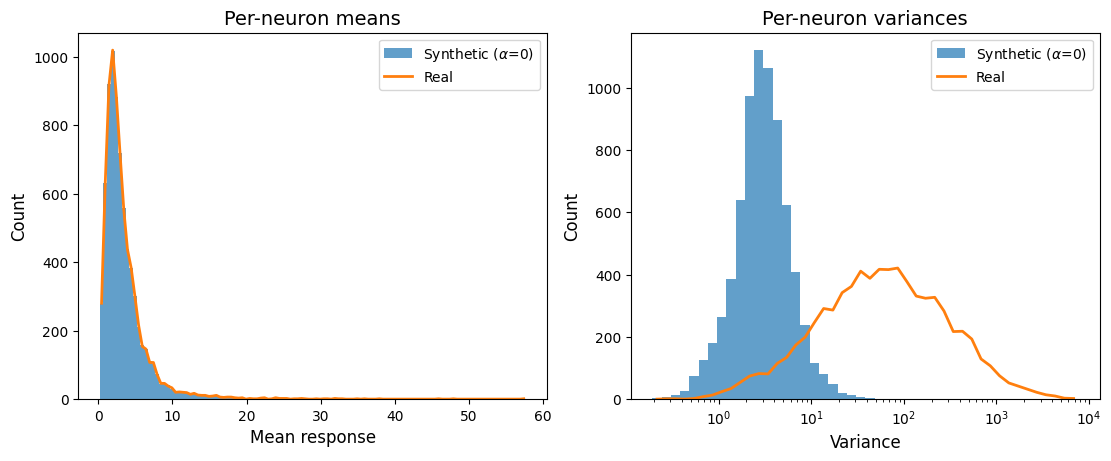

In [48]:
plot_figure_B(session_stats, real_stats=real_stats)

## Latent-dominated

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_marginals_with_real(session_stats, real_stats, K, alpha, savepath=None):
    means = session_stats["per_neuron_mean"]
    vars_ = session_stats["per_neuron_var"]

    means_real = real_stats["per_neuron_mean"]
    vars_real = real_stats["per_neuron_var"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    fig.suptitle(rf'Latent-dominated regime, $K={K}$, $\alpha={alpha:.3g}$', fontsize=16, y=1.03)

    # Means
    bin_width_mean = 0.5
    mean_min = min(means.min(), means_real.min())
    mean_max = max(means.max(), means_real.max())
    bins_mean = np.arange(mean_min, mean_max + bin_width_mean, bin_width_mean)

    axes[0].hist(means, bins=bins_mean, alpha=0.7, density=True, label=rf'Synthetic ($K={K}$)')
    counts_real, edges_real = np.histogram(means_real, bins=bins_mean, density=True)
    centers_real = 0.5 * (edges_real[:-1] + edges_real[1:])
    axes[0].plot(centers_real, counts_real, linewidth=2, label='Real')
    axes[0].set_title('Per-neuron means', fontsize=14)
    axes[0].set_xlabel('Mean response', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=10)
    axes[0].legend(fontsize=10)

    # Variances
    positive_vars = vars_[vars_ > 0]
    positive_vars_real = vars_real[vars_real > 0]

    var_min = min(positive_vars.min(), positive_vars_real.min())
    var_max = max(positive_vars.max(), positive_vars_real.max())

    log_bin_width = 0.12
    log_min = np.log10(var_min)
    log_max = np.log10(var_max)
    bins_var = 10 ** np.arange(log_min, log_max + log_bin_width, log_bin_width)

    axes[1].hist(positive_vars, bins=bins_var, alpha=0.7, density=True, label=rf'Synthetic ($K={K}$)')
    counts_real_var, edges_real_var = np.histogram(positive_vars_real, bins=bins_var, density=True)
    centers_real_var = np.sqrt(edges_real_var[:-1] * edges_real_var[1:])
    axes[1].plot(centers_real_var, counts_real_var, linewidth=2, label='Real')
    axes[1].set_xscale('log')
    axes[1].set_title('Per-neuron variances', fontsize=14)
    axes[1].set_xlabel('Variance', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].tick_params(axis='both', labelsize=10)
    axes[1].legend(fontsize=10)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_marginals_with_real(session_stats, real_stats, K, alpha, savepath=None):
    means = session_stats["per_neuron_mean"]
    vars_ = session_stats["per_neuron_var"]

    means_real = real_stats["per_neuron_mean"]
    vars_real = real_stats["per_neuron_var"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    fig.suptitle(rf'Latent-dominated regime, $K={K}$, $\alpha={alpha:.3g}$', fontsize=15, y=1.05)

    # ---------------------------
    # Means
    # ---------------------------
    bin_width_mean = 0.5
    mean_min = min(means.min(), means_real.min())
    mean_max = max(means.max(), means_real.max())
    bins_mean = np.arange(mean_min, mean_max + bin_width_mean, bin_width_mean)

    # synthetic histogram as bars
    axes[0].hist(means, bins=bins_mean, alpha=0.7, label=rf'Synthetic ($K={K}$)')

    # real histogram as line
    counts_real, edges_real = np.histogram(means_real, bins=bins_mean)
    centers_real = 0.5 * (edges_real[:-1] + edges_real[1:])
    axes[0].plot(centers_real, counts_real, linewidth=2, label='Real')

    axes[0].set_title('Per-neuron means', fontsize=14)
    axes[0].set_xlabel('Mean response', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=10)
    axes[0].legend(fontsize=10)

    # ---------------------------
    # Variances
    # ---------------------------
    positive_vars = vars_[vars_ > 0]
    positive_vars_real = vars_real[vars_real > 0]

    var_min = min(positive_vars.min(), positive_vars_real.min())
    var_max = max(positive_vars.max(), positive_vars_real.max())

    # fixed width in log10-space
    log_bin_width = 0.1
    log_min = np.log10(var_min)
    log_max = np.log10(var_max)
    bins_var = 10 ** np.arange(log_min, log_max + log_bin_width, log_bin_width)

    # synthetic histogram as bars
    axes[1].hist(positive_vars, bins=bins_var, alpha=0.7, label=rf'Synthetic ($K={K}$)')

    # real histogram as line
    counts_real_var, edges_real_var = np.histogram(positive_vars_real, bins=bins_var)
    centers_real_var = np.sqrt(edges_real_var[:-1] * edges_real_var[1:])  # geometric centers
    axes[1].plot(centers_real_var, counts_real_var, linewidth=2, label='Real')

    axes[1].set_xscale('log')
    axes[1].set_title('Per-neuron variances', fontsize=14)
    axes[1].set_xlabel('Variance', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].tick_params(axis='both', labelsize=10)
    axes[1].legend(fontsize=10)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_correlations_for_dataset(data, coords, K, alpha, savepath=None):
    corr = compute_corr(data)

    order = np.lexsort((coords[:, 0], coords[:, 1]))
    corr_ord = corr[order][:, order]

    mask = np.tril(np.ones_like(corr_ord, dtype=bool), k=-1)
    corr_plot = corr_ord.copy()
    corr_plot[mask] = np.nan

    corr_vals = upper_triangle_values(corr)

    eigvals = np.linalg.eigvalsh(corr)
    eigvals = eigvals[::-1]
    eigvals_pos = eigvals[eigvals > 1e-10]
    eigvals_norm = eigvals_pos / eigvals_pos.sum()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    fig.suptitle(rf'Latent-dominated regime, $K={K}$, $\alpha={alpha:.3g}$', fontsize=15, y=1.05)

    # correlation histogram
    bins = np.linspace(-1, 1, 81)
    axes[0].hist(corr_vals, bins=bins, density=True)
    axes[0].set_title('Pairwise correlations', fontsize=14)
    axes[0].set_xlabel('Pearson r', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].tick_params(axis='both', labelsize=10)

    # heatmap
    im = axes[1].imshow(corr_plot, vmin=-1, vmax=1, cmap='coolwarm', interpolation='nearest')
    axes[1].set_title('Correlation heatmap', fontsize=14)
    axes[1].set_xlabel('Spatially ordered neuron index', fontsize=12)
    axes[1].set_ylabel('Spatially ordered neuron index', fontsize=12)
    ticks = sparse_ticks(corr_plot.shape[0], max_ticks=6)
    axes[1].set_xticks(ticks)
    axes[1].set_yticks(ticks)
    axes[1].tick_params(axis='both', labelsize=9)
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Pearson r', fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # eigenspectrum
    x = np.arange(1, len(eigvals_norm) + 1)
    axes[2].plot(x, eigvals_norm, marker='o', markersize=2, linewidth=1)
    axes[2].set_yscale('log')
    axes[2].set_title('Eigenspectrum', fontsize=14)
    axes[2].set_xlabel('Component index', fontsize=12)
    axes[2].set_ylabel('Normalized eigenvalue', fontsize=12)
    axes[2].tick_params(axis='both', labelsize=10)

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

In [42]:
def plot_all_latent_dominated(latent_dom_data, latent_dom_alpha, lat_stats, real_stats, real_data, coords, plot_stats):
    # os.makedirs(save_dir, exist_ok=True)

    for K in sorted(latent_dom_data.keys()):
        data = latent_dom_data[K]
        alpha = latent_dom_alpha[K]
        stats = lat_stats[K]

        if plot_stats:
            plot_marginals_with_real(
                session_stats=stats,
                real_stats=real_stats,
                K=K,
                alpha=alpha,
            )
        else:
            plot_figure_C(
                session_data=data,
                real_data=real_data,
                # savepath=f'latentdom_corr_compare_K{K}.png',
                regime_title=rf'Latent-dominated regime, $K={K}$, $\alpha={alpha:.3g}$'
            )

In [11]:
Ks = [4,8,12,16,20,24]

In [23]:
latent_dom_data = {
    k: load_mouse_responses(f'/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium/k_{k}_a_max_beta1e7_poisson/data/responses') for k in Ks
}

In [15]:
latent_dom_alpha = {k: np.load(f'/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy') for k in Ks}

In [24]:
lat_stats = {}
for K in sorted(latent_dom_data.keys()):
    data = latent_dom_data[K]
    alpha = latent_dom_alpha[K]
    stats = compute_basic_stats(data)
    lat_stats[K] = stats

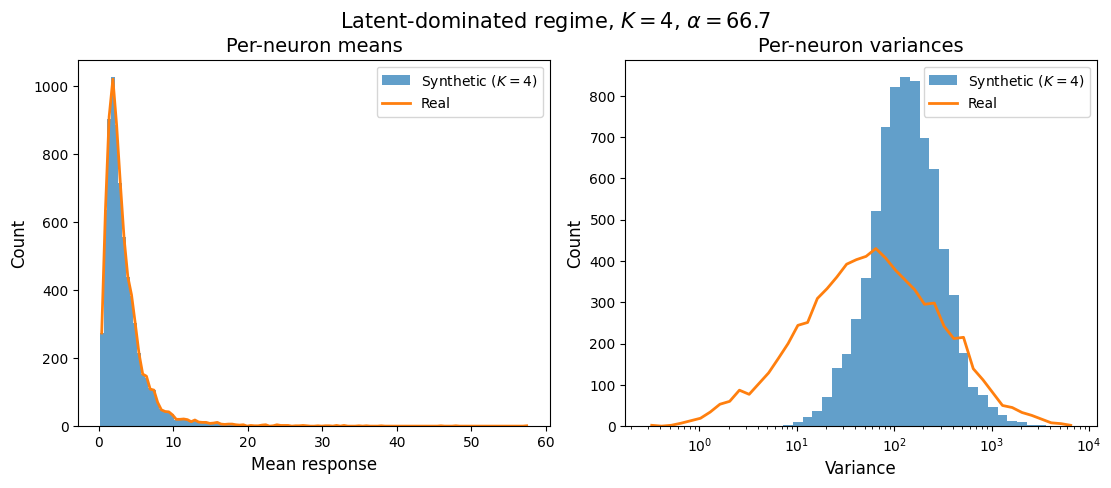

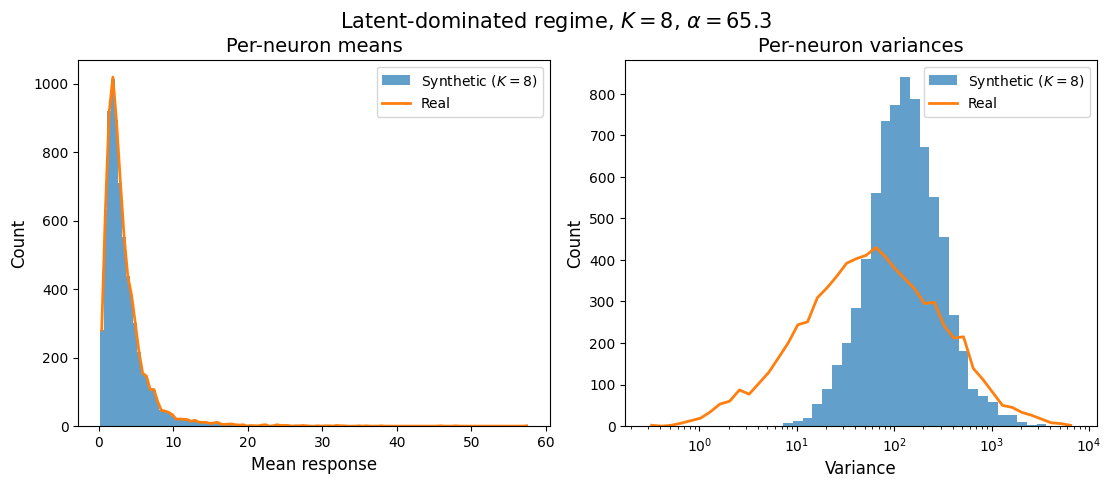

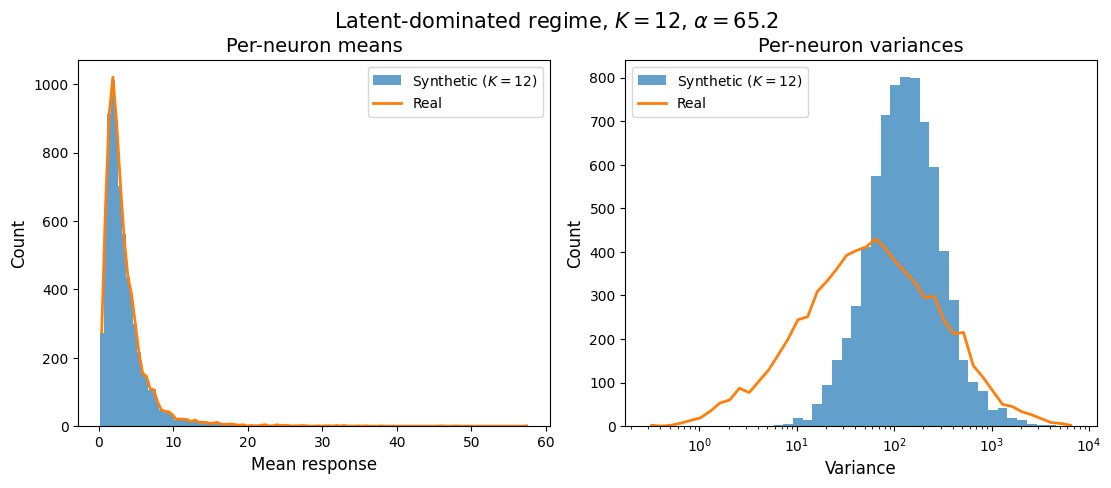

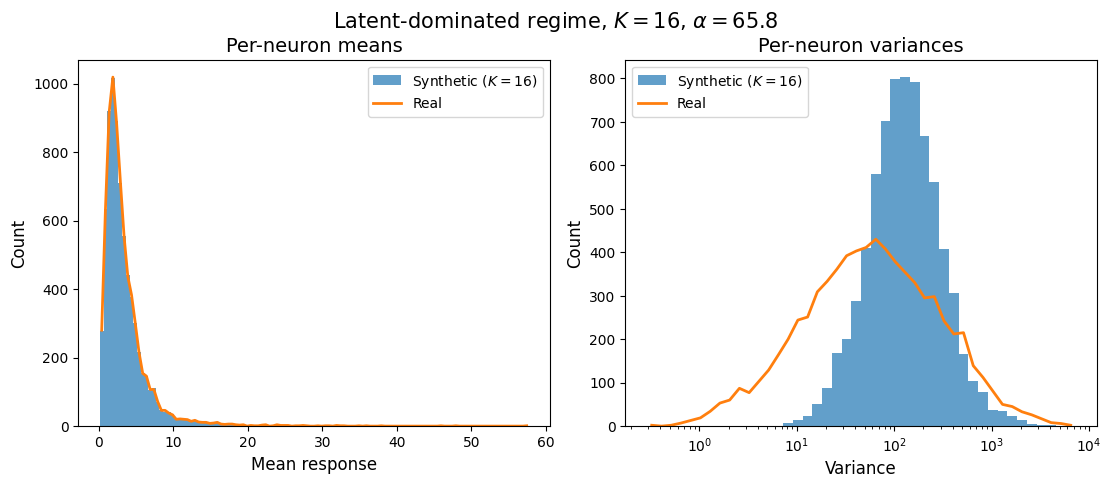

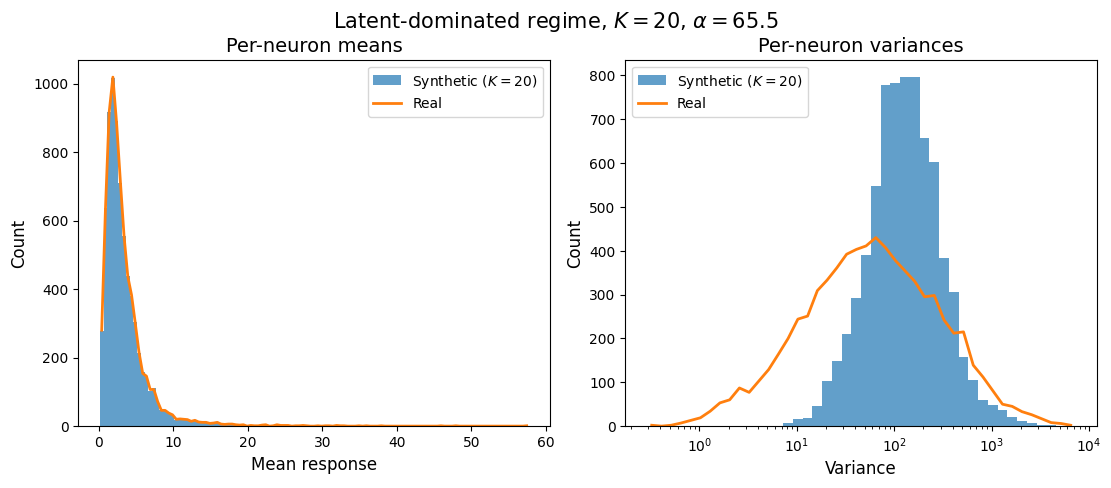

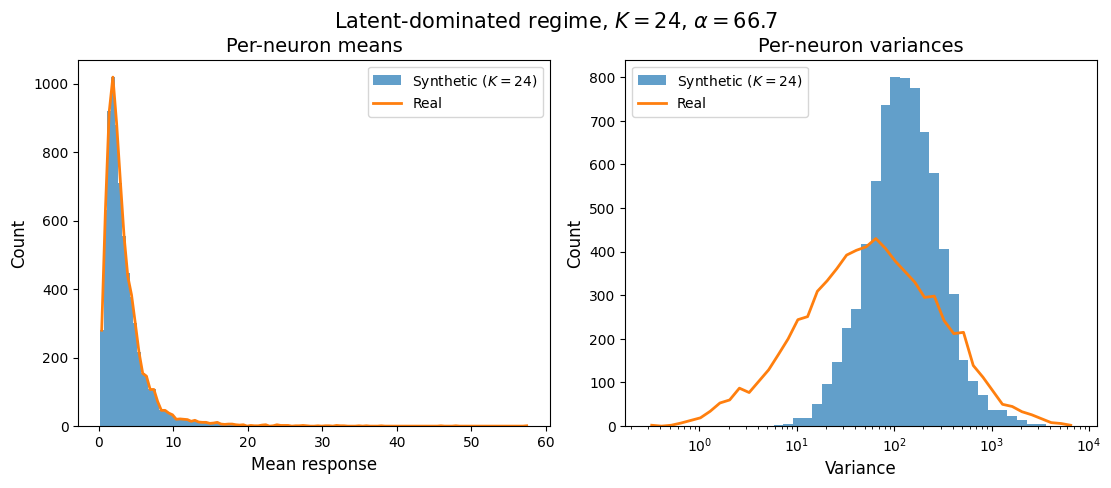

In [31]:
plot_all_latent_dominated(latent_dom_data, latent_dom_alpha, lat_stats, real_stats, coords)

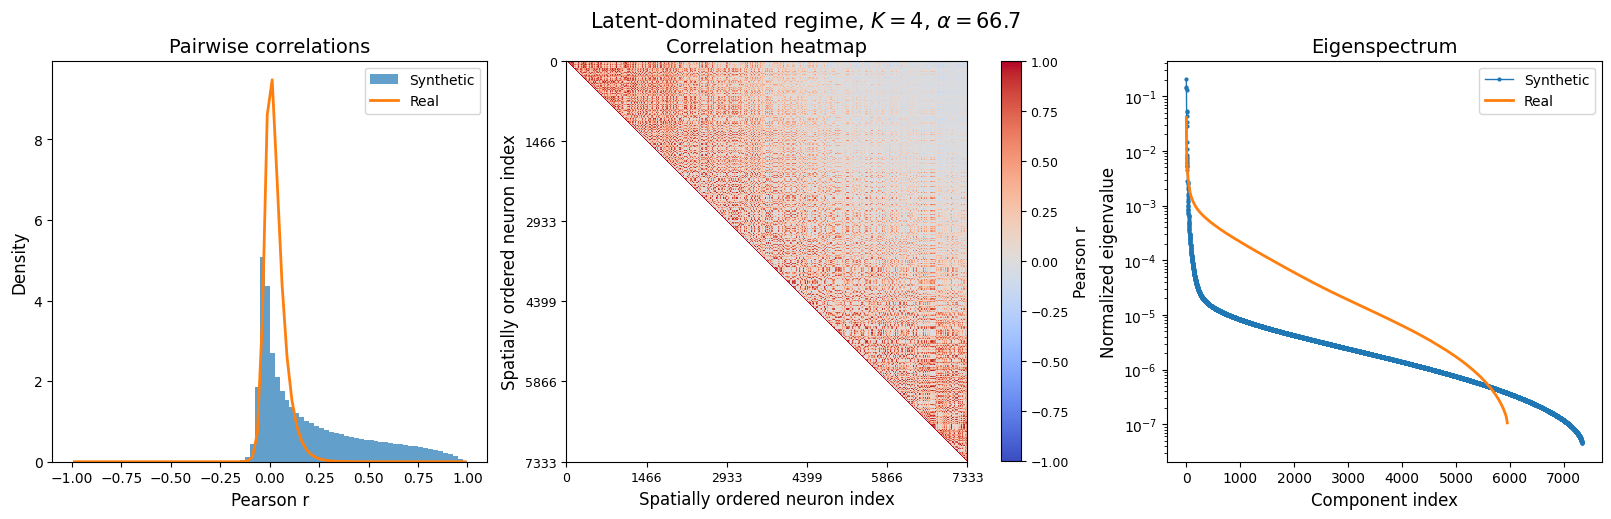

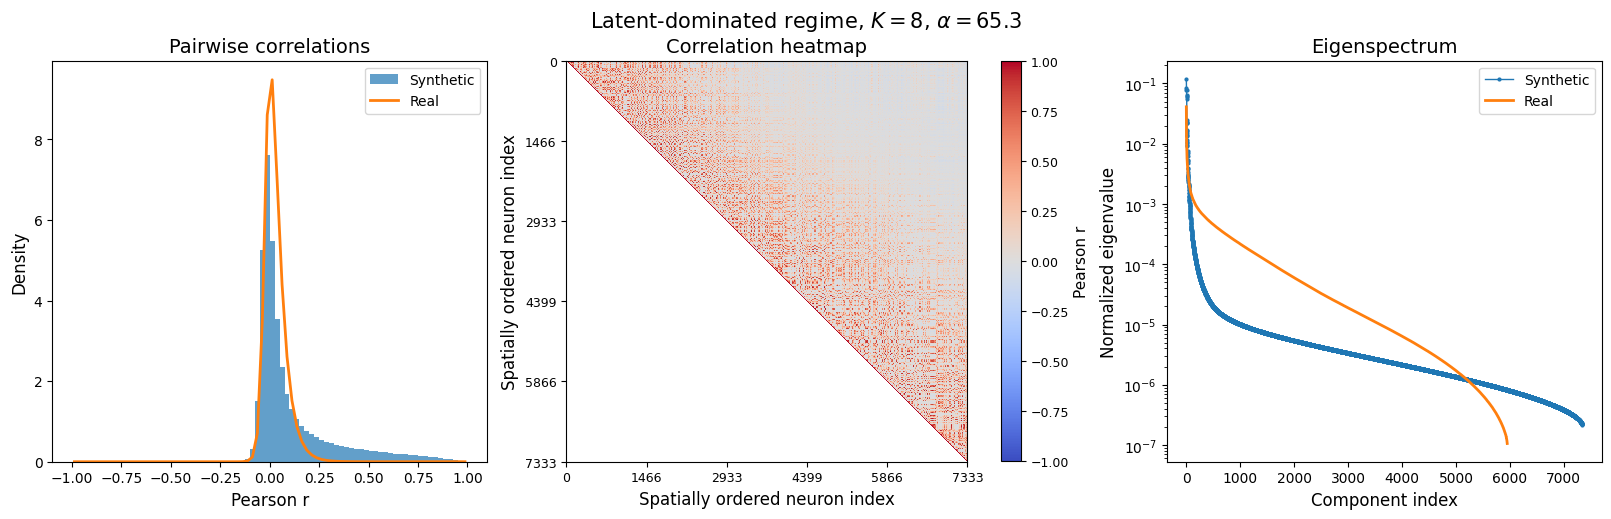

In [ ]:
plot_all_latent_dominated(latent_dom_data, latent_dom_alpha, lat_stats, real_stats, real_data, coords, plot_stats=False)

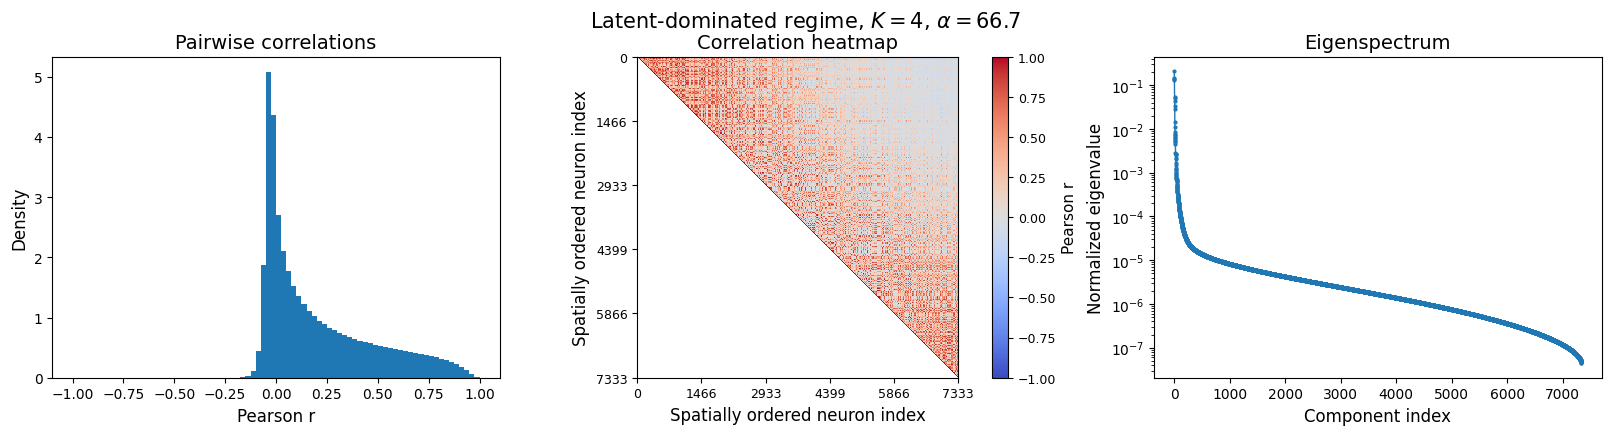

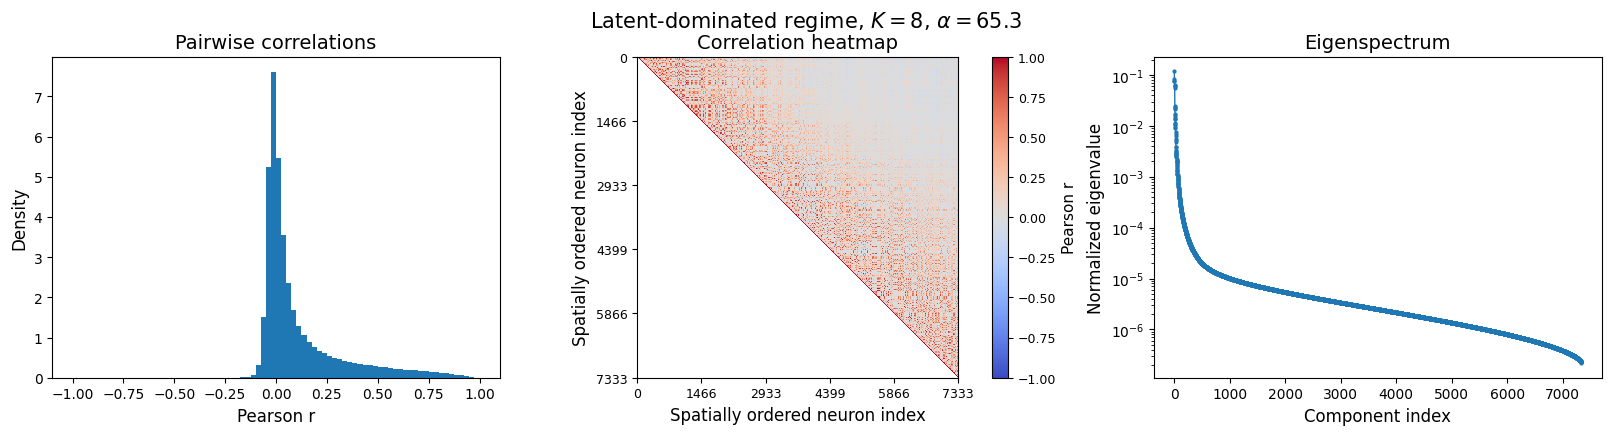

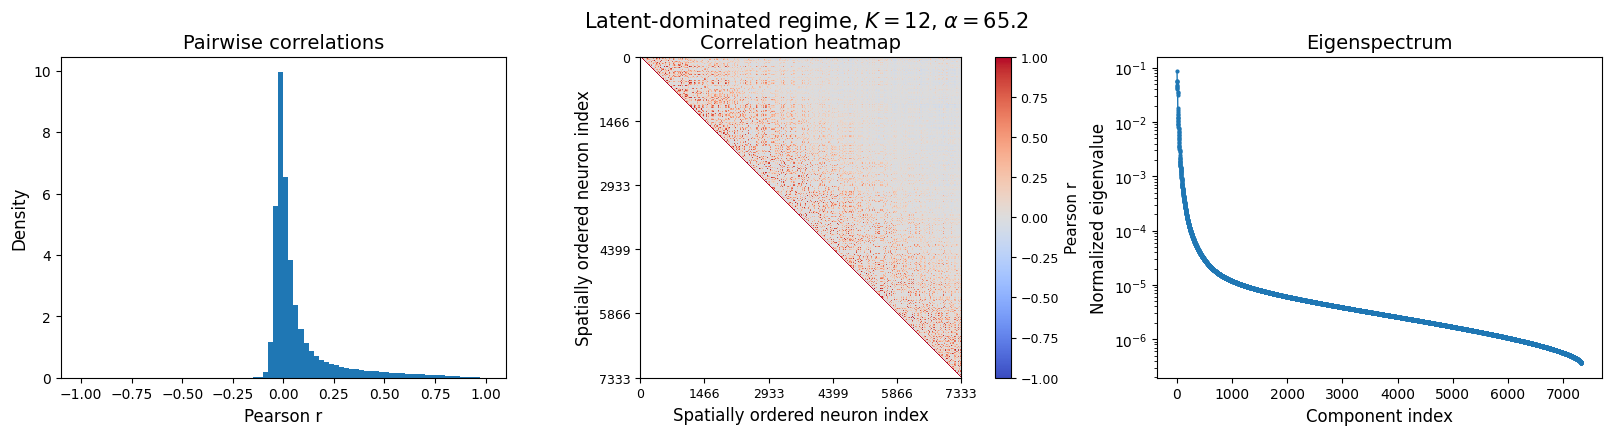

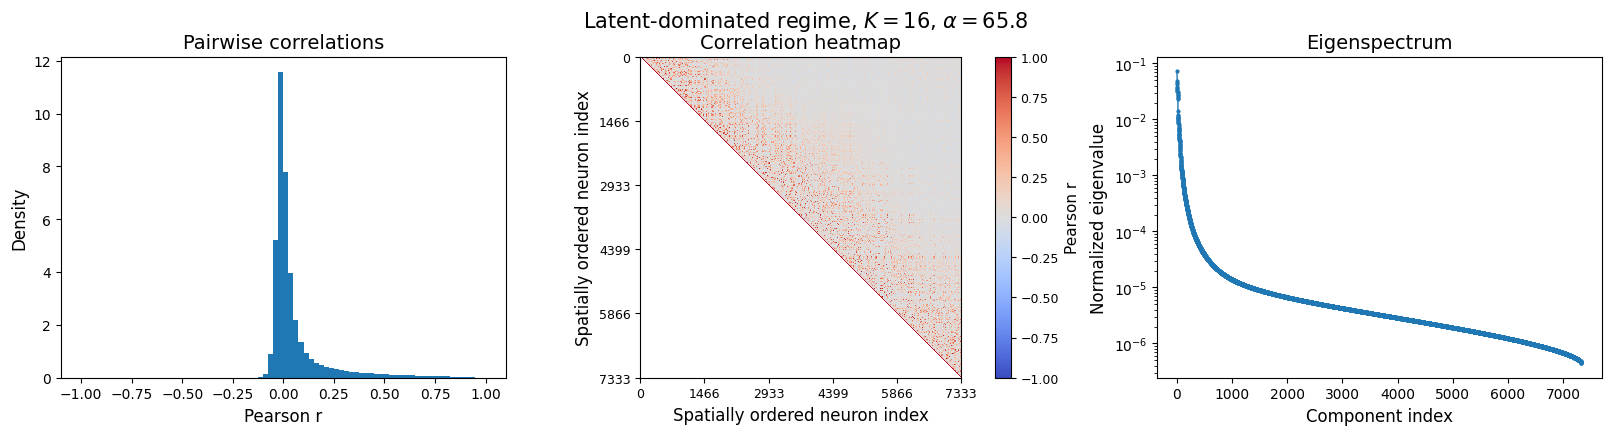

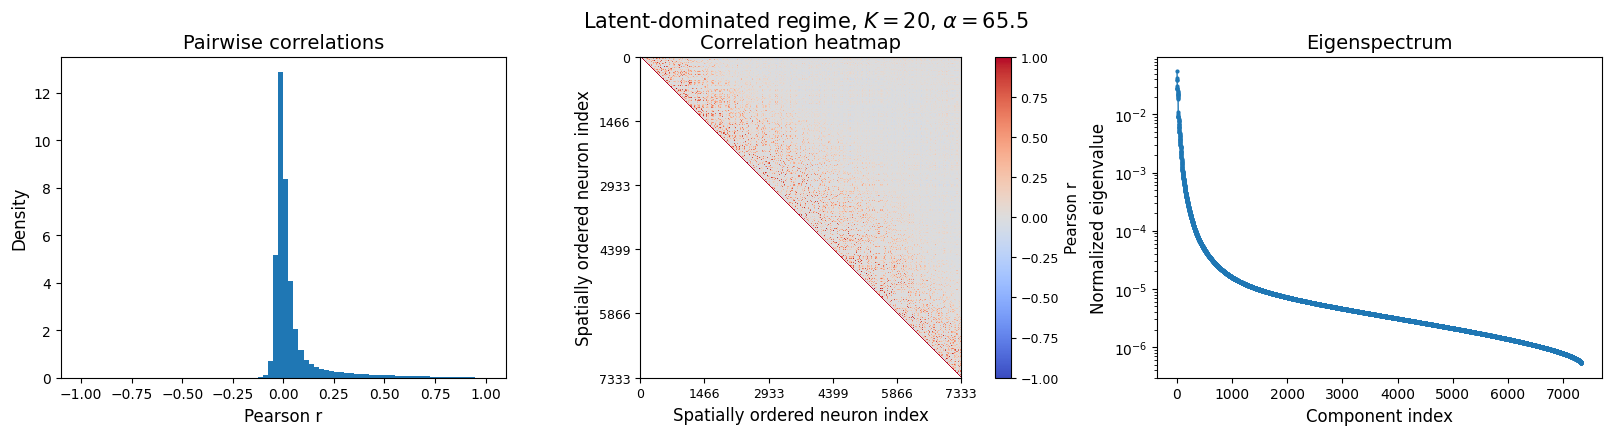

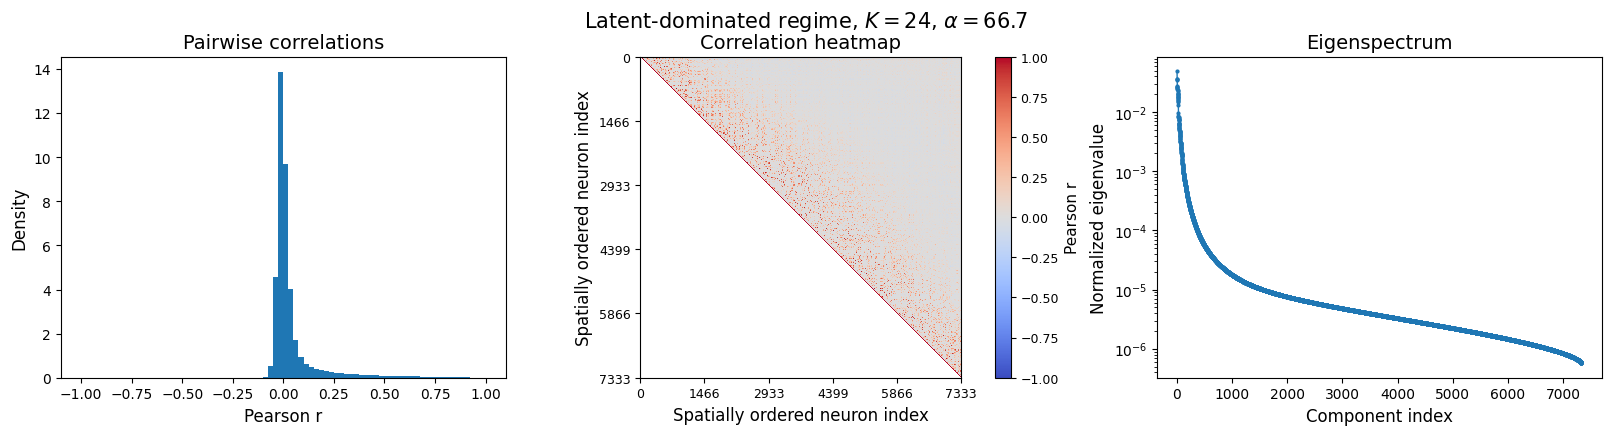

In [ ]:
plot_all_latent_dominated(latent_dom_data, latent_dom_alpha, lat_stats, real_stats, real_data, coords, plot_stats=False)